In [1]:
#Load librabry
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#ML Models
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

#DL models



from sklearn.metrics import mean_squared_error

In [2]:
!pip install yfinance matplotlib pandas statsmodels --quiet

import yfinance as yf

In [5]:
# Example: Fetch last 2 years of Gold prices
gold_data = yf.download("GC=F", start="2022-01-01", end="2024-12-31")

# Example: Fetch Apple stock data
apple_data = yf.download("AAPL", start="2022-01-01", end="2024-12-31")

/tmp/ipython-input-3236539152.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download("GC=F", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3236539152.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_data = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [4]:
apple_data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.443115,179.296076,174.227395,174.345039,104487900
2022-01-04,176.178406,179.354917,175.609770,179.050994,99310400
2022-01-05,171.492081,176.639196,171.217569,176.090173,94537600
2022-01-06,168.629303,171.864636,168.276357,169.315582,96904000
2022-01-07,168.795959,170.727354,167.678301,169.501851,86709100
...,...,...,...,...,...
2024-12-23,254.367035,254.745680,252.553466,253.868804,40858800
2024-12-24,257.286652,257.296596,254.386927,254.586231,23234700


Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2022-01-03  1799.400024  1830.099976  1798.800049  1830.099976    116
2022-01-04  1814.000000  1815.300049  1800.000000  1800.500000     38
2022-01-05  1824.599976  1824.599976  1813.099976  1813.099976      8
2022-01-06  1788.699951  1791.300049  1787.099976  1787.099976     30
2022-01-07  1797.000000  1797.000000  1784.400024  1791.800049     17


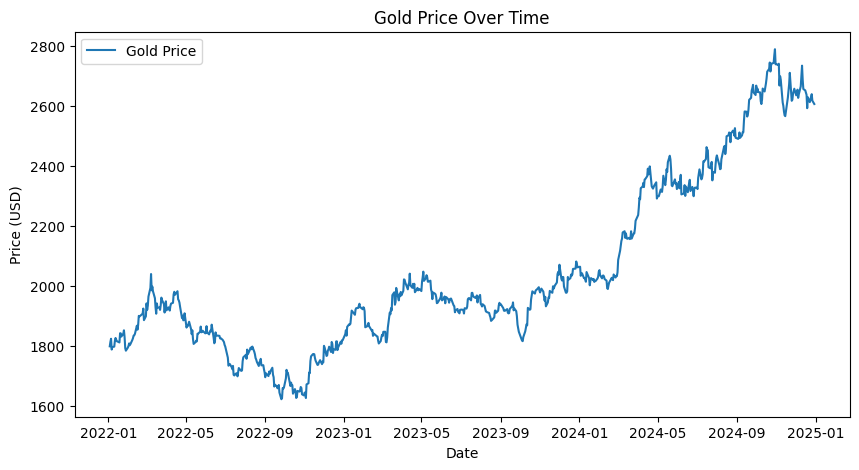

In [6]:
print(gold_data.head())

# Plot Closing Price
plt.figure(figsize=(10,5))
plt.plot(gold_data['Close'], label="Gold Price")
plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

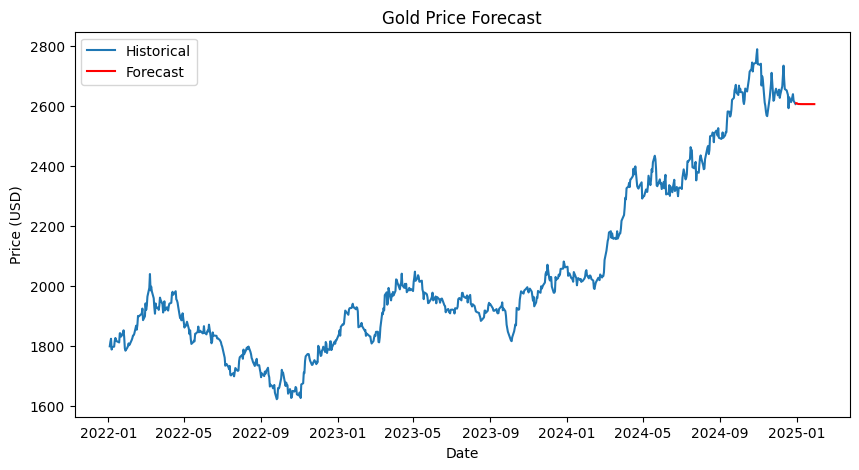

In [7]:
# Use only closing prices
ts = gold_data['Close'].dropna()

# Train ARIMA model (p,d,q) = (5,1,0) as example
model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)

# Plot Forecast
plt.figure(figsize=(10,5))
plt.plot(ts, label="Historical")
plt.plot(pd.date_range(ts.index[-1], periods=31, freq="D")[1:], forecast, label="Forecast", color="red")
plt.title("Gold Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

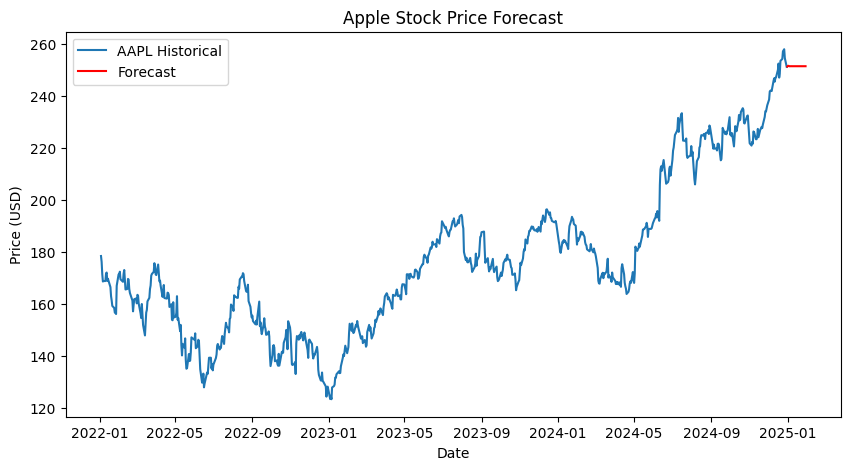

In [8]:
ts = apple_data['Close'].dropna()

model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(ts, label="AAPL Historical")
plt.plot(pd.date_range(ts.index[-1], periods=31, freq="D")[1:], forecast, label="Forecast", color="red")
plt.title("Apple Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [9]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

/tmp/ipython-input-3324276386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GC=F", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


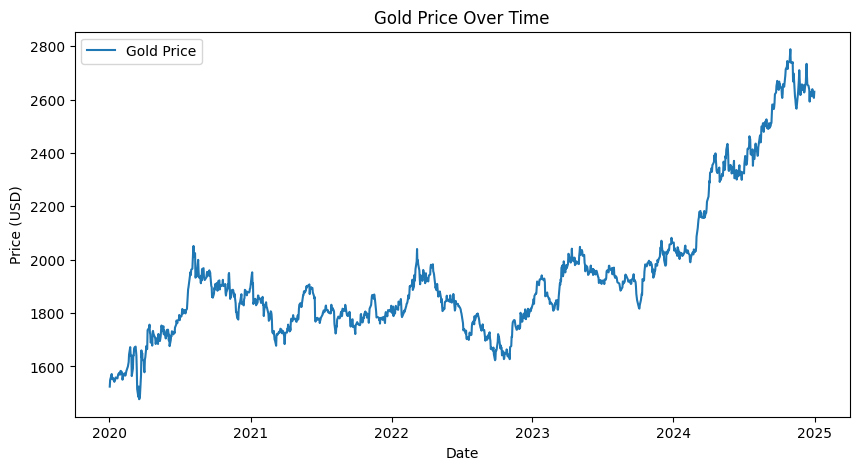

In [10]:
# Fetch GOLD prices (you can replace "GC=F" with "AAPL" for Apple stock)
data = yf.download("GC=F", start="2020-01-01", end="2025-01-01")
prices = data[['Close']]

plt.figure(figsize=(10,5))
plt.plot(prices, label="Gold Price")
plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [11]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(prices)

# Function to create sequences
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data)-time_steps-1):
        X.append(data[i:(i+time_steps), 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

# Reshape for RNN/LSTM [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [12]:
rnn_model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(time_steps,1)),
    SimpleRNN(50),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
history_rnn = rnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.2398 - val_loss: 0.2038
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0055 - val_loss: 0.1510
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0022 - val_loss: 0.1133
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019 - val_loss: 0.0869
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0015 - val_loss: 0.0620
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0012 - val_loss: 0.0518
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 9.0489e-04 - val_loss: 0.0434
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.0821e-04 - val_loss: 0.0311
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 9.2022e-04 - val_loss: 0.0306
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.9348e-04 - val_loss: 0.0308
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.1806e-04 - val_loss: 0.0244
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2

In [13]:
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps,1)),
    LSTM(50),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
history_lstm = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0290 - val_loss: 0.0217
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 0.0015 - val_loss: 0.0203
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 9.9411e-04 - val_loss: 0.0087
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 8.0254e-04 - val_loss: 0.0022
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 8.9443e-04 - val_loss: 0.0025
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 7.4802e-04 - val_loss: 0.0019
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 7.1635e-04 - val_loss: 0.0028
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 7.0225e-04 - val_loss: 0.0015
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 6.8920e-04 - val_loss: 0.0018
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 6.8065e-04 - val_loss: 0.0019
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 6.5739e-04 - val_loss: 0.0012
Epoch 12/20
30/30 ━━━━━━━━

In [14]:
# RNN Predictions
rnn_pred = rnn_model.predict(X_test)
rnn_pred = scaler.inverse_transform(rnn_pred.reshape(-1,1))
real_prices = scaler.inverse_transform(y_test.reshape(-1,1))

# LSTM Predictions
lstm_pred = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred.reshape(-1,1))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


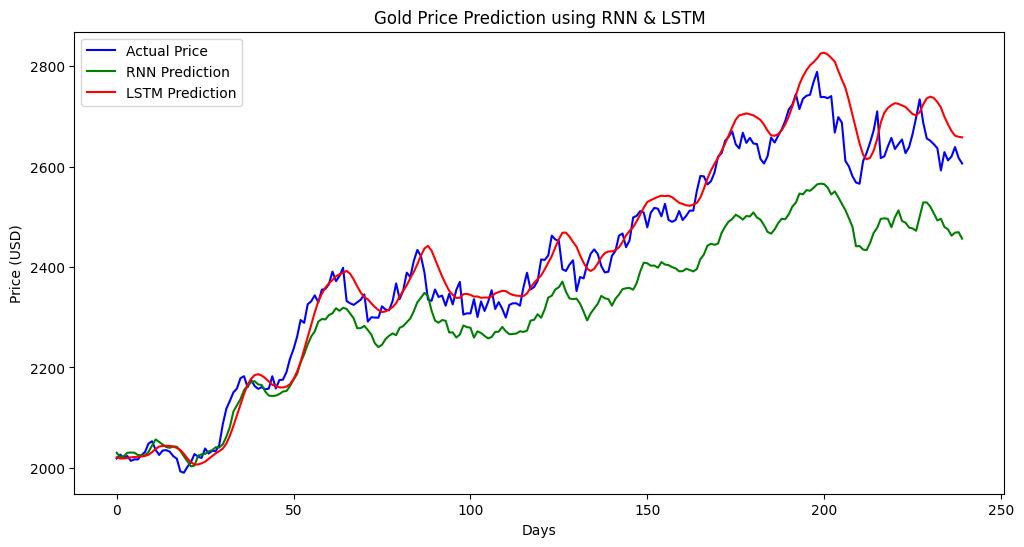

In [15]:
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Actual Price", color="blue")
plt.plot(rnn_pred, label="RNN Prediction", color="green")
plt.plot(lstm_pred, label="LSTM Prediction", color="red")
plt.title("Gold Price Prediction using RNN & LSTM")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

/tmp/ipython-input-2357119472.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GC=F", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


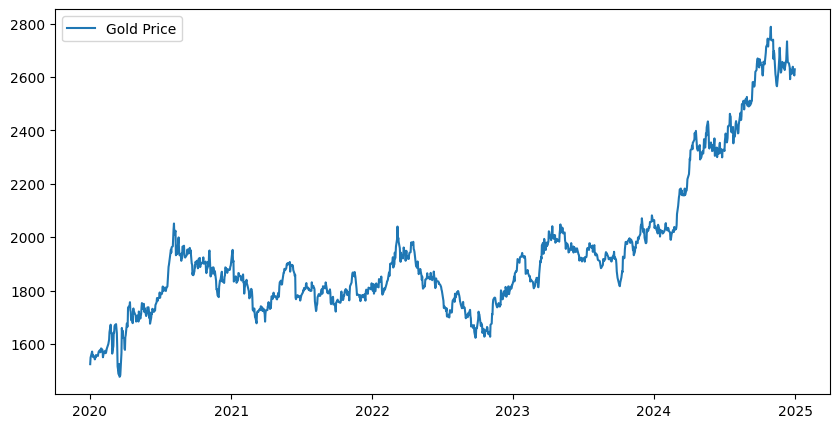

In [17]:
# Example: Gold Futures (GC=F) OR Apple stock (AAPL)
data = yf.download("GC=F", start="2020-01-01", end="2025-01-01")
prices = data[['Close']]

plt.figure(figsize=(10,5))
plt.plot(prices, label="Gold Price")
plt.legend(); plt.show()


In [18]:
# Scale
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(prices)

# Create sequences
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data)-time_steps):
        X.append(data[i:i+time_steps, 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 60
X, y = create_sequences(scaled_data, time_steps)

# Train/Test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape: [samples, time_steps, features]
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)


In [19]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

# Build Transformer model
inputs = layers.Input(shape=(time_steps, 1))
x = transformer_encoder(inputs, head_size=64, num_heads=2, ff_dim=64, dropout=0.1)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1)(x)

transformer_model = tf.keras.Model(inputs, outputs)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 1)     │          2 │ input_layer_2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │        897 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 1)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │        128 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 1)     │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 1)     │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,287 (5.03 KB)

 Trainable params: 1,287 (5.03 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0618 - val_loss: 0.1562
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0050 - val_loss: 0.1473
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0044 - val_loss: 0.1232
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0039 - val_loss: 0.1234
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0037 - val_loss: 0.1227
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0039 - val_loss: 0.1133
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0039 - val_loss: 0.1124
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0037 - val_loss: 0.1098
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0039 - val_loss: 0.1094
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0036 - val_loss: 0.0997
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0031 - val_loss: 0.0939
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


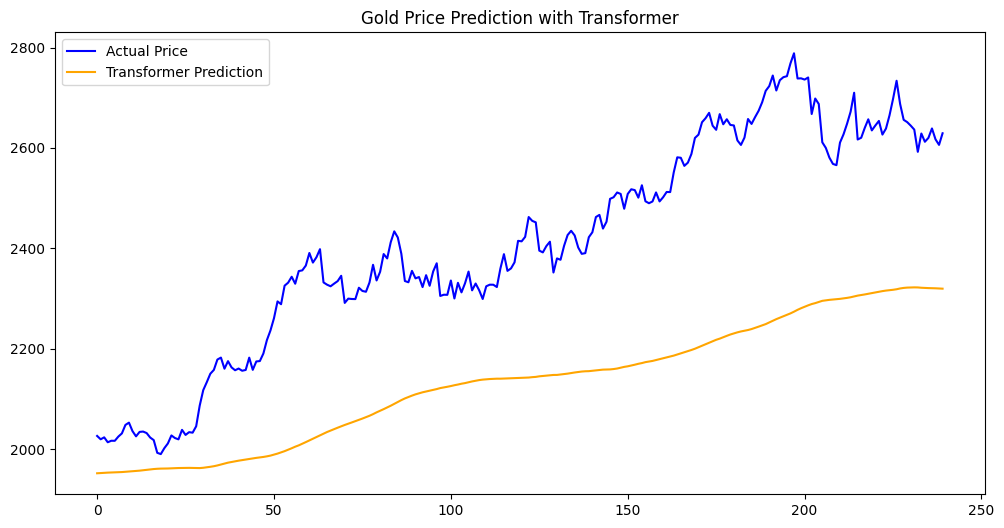

In [21]:
preds = transformer_model.predict(X_test)
preds_rescaled = scaler.inverse_transform(preds)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label="Actual Price", color="blue")
plt.plot(preds_rescaled, label="Transformer Prediction", color="orange")
plt.title("Gold Price Prediction with Transformer")
plt.legend(); plt.show()
